<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/UASPCVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Data

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arayakautsar","key":"711b00e4808db943bbd36121300b7328"}'}

In [ ]:
# Membuat folder .kaggle
!mkdir -p ~/.kaggle

# Memindahkan kaggle.json ke folder ini
!cp kaggle.json ~/.kaggle/

# Memberikan permission agar terbaca
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 4.66G/4.66G [03:03<00:00, 25.2MB/s]
100% 4.66G/4.66G [03:03<00:00, 27.3MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile('fruits.zip', 'r') as zip_ref:
    zip_ref.extractall('fruits_dataset')


# Pemetaan Ulang Label

In [ ]:
import os
import shutil

# =============================================================
# 1. DEFINISI KATEGORI BUAH (prefix-based)
# =============================================================

# --- POME ---
apple_classes = [
    "Apple Crimson Snow",
    "Apple Golden",
    "Apple Granny Smith",
    "Apple Pink Lady",
    "Apple Red",
    "Apple Red Delicious"
]

pear_classes = [
    "Pear Abate",
    "Pear Forelle",
    "Pear Kaiser",
    "Pear Monster",
    "Pear Red",
    "Pear Stone",
    "Pear Williams",
    ]

# --- DRUPE ---
drupe_classes = [
    "Apricot",
    "Nectarine",
    "Nectarine Flat",
    "Peach",
    "Peach Flat"
]

categories = {
    "Pome": apple_classes + pear_classes,
    "Drupe": drupe_classes
}

# =============================================================
# 2. PEMETAAN LABEL
# =============================================================

def map_label_to_category(class_name):
    for kategori, daftar_prefix in categories.items():
        for prefix in daftar_prefix:
            if class_name.startswith(prefix):
                return kategori
    return None


# =============================================================
# 3. SETUP FOLDER INPUT
# =============================================================

train_source = "fruits_dataset/fruits-360_100x100/fruits-360/Training"
test_source  = "fruits_dataset/fruits-360_100x100/fruits-360/Test"

train_output = "fruits_remapped(Pome&Drupe)/train"
test_output  = "fruits_remapped(Pome&Drupe)/test"

os.makedirs(train_output, exist_ok=True)
os.makedirs(test_output, exist_ok=True)

# =============================================================
# 4. FUNGSI REMAP DATASET
# =============================================================

def remap_dataset(source_dir, output_dir, label="TRAIN"):
    count = {"Pome": 0, "Drupe": 0}

    print(f"\n=== PROSES REMAP DATASET {label} DIMULAI ===")

    for class_name in os.listdir(source_dir):

        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        kategori = map_label_to_category(class_name)

        if kategori is None:
            print(f"Skip (bukan Pome/Drupe): {class_name}")
            continue

        target_folder = os.path.join(output_dir, kategori, class_name)
        os.makedirs(target_folder, exist_ok=True)

        for img in os.listdir(class_path):
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(target_folder, img)
            )

        count[kategori] += 1
        print(f"✔ {class_name} → {kategori}")

    print(f"\n=== REMAP {label} SELESAI ===")
    print("Total Pome :", count["Pome"])
    print("Total Drupe:", count["Drupe"])
    print("Folder output:", output_dir)


# =============================================================
# 5. JALANKAN REMAP UNTUK TRAIN & TEST
# =============================================================

remap_dataset(train_source, train_output, label="TRAIN")
remap_dataset(test_source, test_output, label="TEST")


=== PROSES REMAP DATASET TRAIN DIMULAI ===
✔ Pear Kaiser 1 → Pome
Skip (bukan Pome/Drupe): Cucumber 4
✔ Apple Granny Smith 1 → Pome
Skip (bukan Pome/Drupe): Grape White 1
Skip (bukan Pome/Drupe): Cherry Wax not ripen 2
Skip (bukan Pome/Drupe): Cucumber 5
Skip (bukan Pome/Drupe): Tomato Cherry Red 1
Skip (bukan Pome/Drupe): Pepper Yellow 1
Skip (bukan Pome/Drupe): Nut 5
Skip (bukan Pome/Drupe): Nut 4
Skip (bukan Pome/Drupe): Pepper Red 1
Skip (bukan Pome/Drupe): Banana Red 1
✔ Apple Red Yellow 2 → Pome
Skip (bukan Pome/Drupe): Grape White 3
Skip (bukan Pome/Drupe): Onion White Peeled 1
Skip (bukan Pome/Drupe): Apple 9
✔ Apple Golden 2 → Pome
Skip (bukan Pome/Drupe): Apple 13
Skip (bukan Pome/Drupe): Apple hit 1
Skip (bukan Pome/Drupe): Apple 18
Skip (bukan Pome/Drupe): Pear 3
Skip (bukan Pome/Drupe): Pear 6
Skip (bukan Pome/Drupe): Orange 1
Skip (bukan Pome/Drupe): Carambula 1
Skip (bukan Pome/Drupe): Mangostan 1
Skip (bukan Pome/Drupe): Strawberry 1
Skip (bukan Pome/Drupe): Pepper Gre

#Analisis Citra Gambar

##Ambil beberapa citra dari objek berbeda dan bandingkan kualitasnya berdasarkan pencahayaan dan resolusi sesuai tema masing-masing.

###Ambil 10 citra (apel 3, pear 3, apricote 1, nectarine 2, peach 1)
analisis kualitas citra meliputi

* brightness & ketajaman
* Resolusi & ukuran pixel
* Noise
* Tekstur

In [ ]:
pip install scikit-image

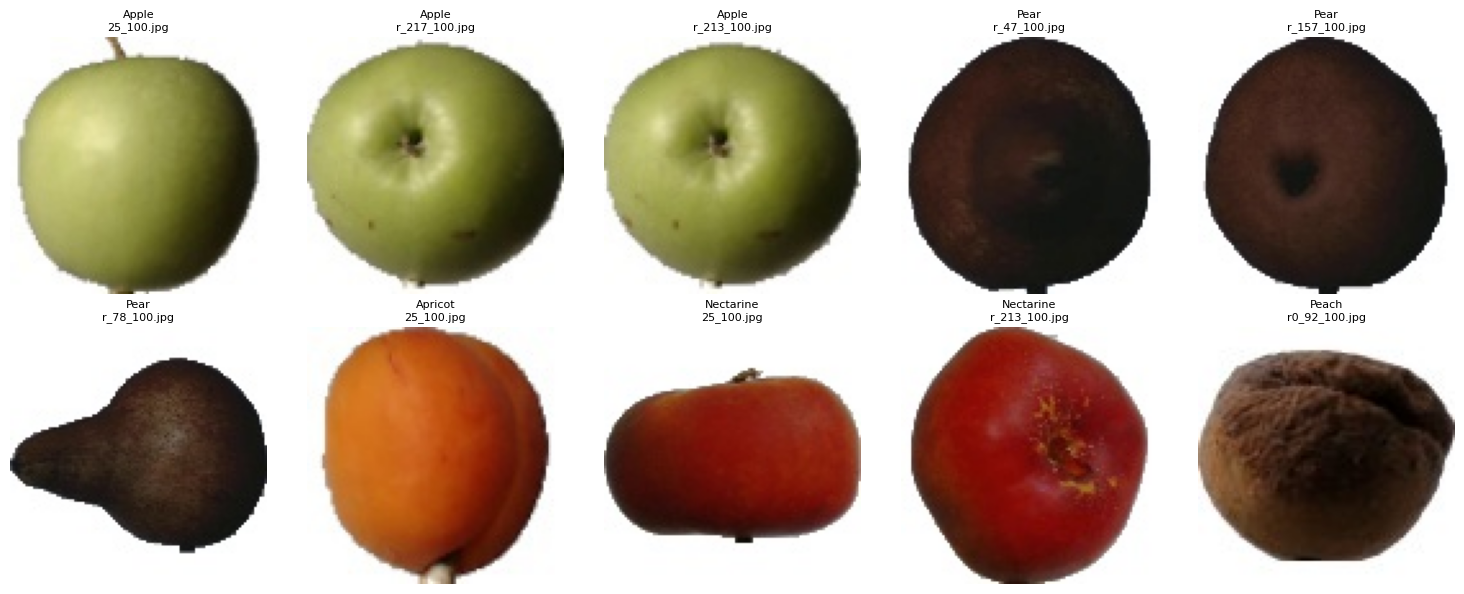


=== HASIL ANALISIS KUALITAS CITRA ===

       Kelas           File  Brightness  Contrast(std)  Sharpness(Laplacian)  \
0      Apple     25_100.jpg  154.409133      80.739294            845.221906   
1      Apple  r_217_100.jpg  142.410933      80.800516            695.715420   
2      Apple  r_213_100.jpg  143.266167      80.570298            739.792091   
3       Pear   r_47_100.jpg   88.477800      99.595877           3792.917886   
4       Pear  r_157_100.jpg   95.525033      98.717450           3921.706744   
5       Pear   r_78_100.jpg  150.231400     109.282894           3967.010561   
6    Apricot     25_100.jpg  138.060733      94.054105            788.313079   
7  Nectarine     25_100.jpg  146.720367     105.555652           1469.571658   
8  Nectarine  r_213_100.jpg  115.387033      98.393684           1679.835041   
9      Peach  r0_92_100.jpg  118.593133     102.722965           1264.026746   

     Noise(var) Resolution  Size(KB)  Tex_Contrast  Tex_Homogeneity  \
0  12623

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# ==========================================================
# KONFIGURASI
# ==========================================================

dataset_dir = "fruits_remapped(Pome&Drupe)/train"

sample_targets = {
    "Apple": 3,
    "Pear": 3,
    "Apricot": 1,
    "Nectarine": 2,
    "Peach": 1
}

# ==========================================================
# FUNGSI ANALISIS CITRA
# ==========================================================

def analyze_image(image_path):
    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Brightness & Contrast
    brightness = np.mean(rgb)
    contrast_std = np.std(rgb)

    # Sharpness (Laplacian Variance)
    sharpness_val = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Noise Estimation (Residual of Gaussian blur)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    noise_val = (gray - blur).var()

    # Resolution
    h, w = rgb.shape[:2]
    resolution = f"{w}x{h}"

    # File size
    size_kb = os.path.getsize(image_path) / 1024

    # Texture (GLCM)
    glcm = graycomatrix(gray, distances=[5], angles=[0], levels=256,
                        symmetric=True, normed=True)

    tex_contrast     = graycoprops(glcm, 'contrast')[0, 0]
    tex_homogeneity  = graycoprops(glcm, 'homogeneity')[0, 0]
    tex_energy       = graycoprops(glcm, 'energy')[0, 0]
    tex_correlation  = graycoprops(glcm, 'correlation')[0, 0]

    return (
        brightness, contrast_std, sharpness_val,
        noise_val, resolution, size_kb,
        tex_contrast, tex_homogeneity, tex_energy, tex_correlation,
        rgb
    )


# ==========================================================
# AMBIL SAMPEL GAMBAR
# ==========================================================

samples = []

for kelas, jumlah in sample_targets.items():
    found = False
    for kategori in ["Pome", "Drupe"]:
        class_folder = os.path.join(dataset_dir, kategori)

        for folder_name in os.listdir(class_folder):
            if folder_name.startswith(kelas):
                folder_path = os.path.join(class_folder, folder_name)

                img_files = os.listdir(folder_path)[:jumlah]

                for img_name in img_files:
                    img_path = os.path.join(folder_path, img_name)
                    samples.append((kelas, img_path))

                found = True
                break

        if found:
            break


# ==========================================================
# ANALISIS DAN VISUALISASI
# ==========================================================

analisis = []

num_images = len(samples)
num_cols = 5
num_rows = (num_images + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 3, num_rows * 3))

for idx, (kelas, path) in enumerate(samples):
    (
        brightness, contrast_std, sharpness_val,
        noise_val, resolution, size_kb,
        tex_contrast, tex_homogeneity, tex_energy, tex_correlation,
        img_rgb
    ) = analyze_image(path)

    analisis.append([
        kelas, os.path.basename(path),
        brightness, contrast_std, sharpness_val,
        noise_val, resolution, size_kb,
        tex_contrast, tex_homogeneity, tex_energy, tex_correlation
    ])

    plt.subplot(num_rows, num_cols, idx + 1)
    plt.imshow(img_rgb)
    plt.title(f"{kelas}\n{os.path.basename(path)}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


# ==========================================================
# TAMPILKAN TABEL HASIL
# ==========================================================

df = pd.DataFrame(analisis, columns=[
    "Kelas", "File",
    "Brightness", "Contrast(std)", "Sharpness(Laplacian)",
    "Noise(var)", "Resolution", "Size(KB)",
    "Tex_Contrast", "Tex_Homogeneity", "Tex_Energy", "Tex_Correlation"
])

print("\n=== HASIL ANALISIS KUALITAS CITRA ===\n")
print(df)


=== HISTOGRAM TIAP CITRA ===



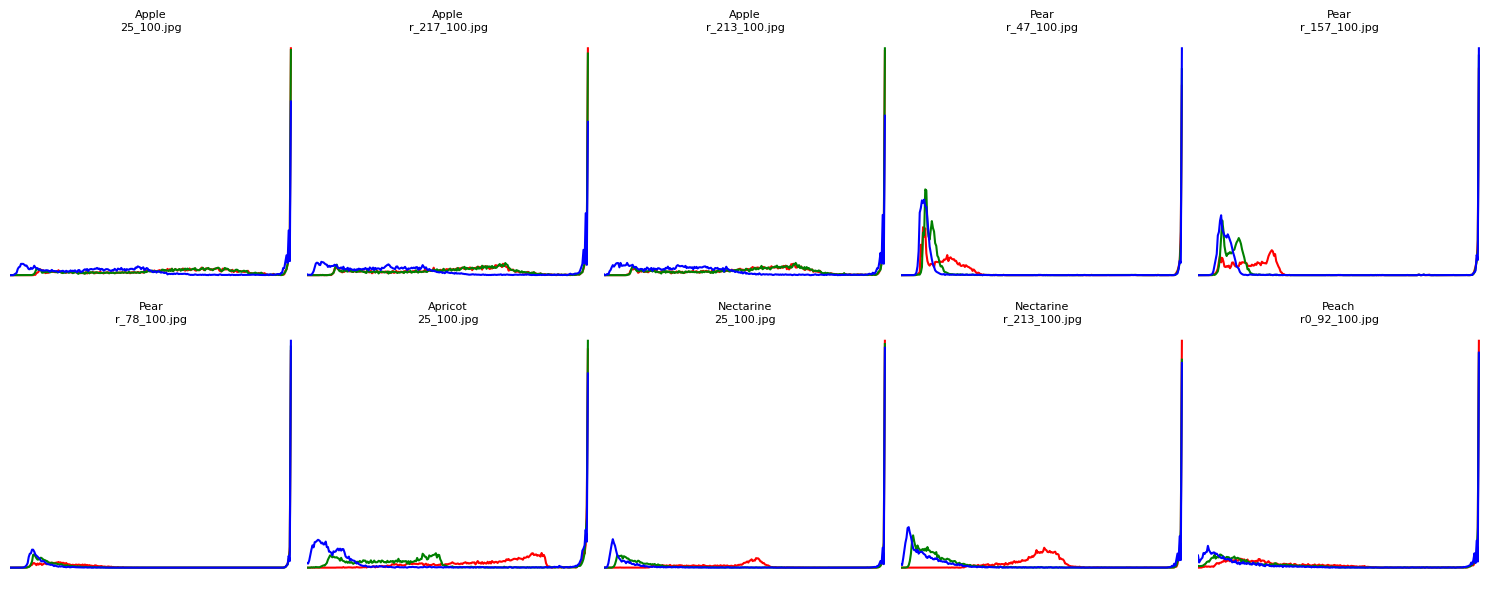

In [ ]:
num_images = len(samples)
num_cols = 5
num_rows = 2  # karena 10 citra

plt.figure(figsize=(num_cols*3, num_rows*3))

for idx, (kelas, path) in enumerate(samples):
    # Baca citra RGB
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Hitung histogram per channel
    colors = ('r','g','b')
    hist_data = [cv2.calcHist([img_rgb],[i],None,[256],[0,256]) for i in range(3)]

    # Buat subplot
    plt.subplot(num_rows, num_cols, idx + 1)

    for i, col in enumerate(colors):
        plt.plot(hist_data[i], color=col)
        plt.xlim([0,256])

    # Judul subplot: kelas + nama file
    plt.title(f"{kelas}\n{os.path.basename(path)}", fontsize=8)
    plt.axis("off")  # nonaktifkan axis agar rapi

print("\n=== HISTOGRAM TIAP CITRA ===\n")
plt.tight_layout()
plt.show()

###Hasil Perbandingan

10 citra objek menunjukkan nilai brightnes dan kontras yang kurang lebih sama, serta dapat juga dilihat berdasarkan histogram bahwa ke-10 citra memiliki kontras yang kurang baik karena persebaran pixelnya kurang merata, selain itu citra cenderung sedikit terang dengan tingginya jumlah pixel yang berda dikisaran 255. Resolusi yang dimiliki tiap gambar juga sama yaitu 100X100. Yang dapat menjadi pembeda utama dalah distribusi warna RGB. Selain distribusi warna RGB, fitur tekstur citra yang dihitung melalui GLCM (Tex_Contrast, Tex_Homogeneity, Tex_Energy, Tex_Correlation) serta ketajaman (Sharpness) juga dapat menjadi pembeda utama antar citra. Nilai-nilai ini membantu membedakan permukaan buah yang halus, bercak, atau fuzzy, meskipun brightness, kontras, dan resolusi tiap gambar relatif sama.

##Analisis perbedaan visual dari setiap kelas.

###Analisis warna dan tekstur tiap kelas

Warna + Tekstur + Bentuk + Ukuran + Pola/Detail + Pencahayaan
<br><br>
contoh : <br>
Apple Crimson Snow: Buah bulat dengan permukaan halus dan mengkilap, warna merah dan hijau seragam, pencahayaan cukup terang, citra tajam.

In [ ]:
import os

# ==============================
# DESKRIPSI DASAR PER KELAS
# ==============================

deskripsi_kelas = {
    "Apple": {
        "warna": "Warna dominan merah, hijau, atau kombinasi merah–kuning. Warna cenderung solid dan seragam dengan permukaan mengkilap.",
        "tekstur": "Tekstur kulit halus dan licin, kadang ada titik pori-pori kecil.",
        "bentuk": "Bulat sempurna atau sedikit gepeng, simetris.",
        "ukuran": "Ukuran sedang (6–10 cm).",
        "pola": "Tidak banyak pola, permukaan bersih dengan gradasi warna lembut.",
        "pencahayaan": "Highlight kuat karena kulit reflektif; citra biasanya cerah."
    },
    "Pear": {
        "warna": "Hijau kekuningan atau kecoklatan, warna sering tidak seragam dengan bercak halus.",
        "tekstur": "Tekstur berbintik (freckles) dan lebih kasar dibanding apel.",
        "bentuk": "Bagian atas kecil dan bawah membesar (bentuk lonceng).",
        "ukuran": "Sedang hingga besar.",
        "pola": "Bercak kecil tersebar; pola tidak smooth.",
        "pencahayaan": "Highlight rendah karena kulit tidak mengkilap."
    },
    "Apricot": {
        "warna": "Warna dominan oranye matte, terkadang kekuningan.",
        "tekstur": "Sedikit berbulu, tekstur lembut seperti velvet.",
        "bentuk": "Bulat kecil, tidak selalu simetris.",
        "ukuran": "Kecil, lebih kecil dari peach.",
        "pola": "Ada garis tengah tipis, permukaan berbutir halus.",
        "pencahayaan": "Cenderung netral, tidak banyak highlight."
    },
    "Nectarine": {
        "warna": "Campuran merah–oranye–kuning dengan gradasi kuat.",
        "tekstur": "Kulit halus tanpa bulu, cukup mengkilap.",
        "bentuk": "Bulat sedikit lonjong, kadang ada lekukan garis tengah.",
        "ukuran": "Ukuran sedang.",
        "pola": "Gradasi warna kompleks, area merah lebih gelap.",
        "pencahayaan": "Highlight terlihat jelas karena kulit glossy."
    },
    "Peach": {
        "warna": "Kuning–oranye dengan pipi kemerahan.",
        "tekstur": "Kulit berbulu (fuzzy), tampak lembut dan kurang reflektif.",
        "bentuk": "Bulat dengan lekukan tengah.",
        "ukuran": "Ukuran sedang.",
        "pola": "Pola warna lembut dengan transisi halus.",
        "pencahayaan": "Tidak menghasilkan highlight kuat karena permukaan berbulu."
    }
}


# ==============================
# FUNGSI ANALISIS TIAP KELAS
# ==============================

def analisis_visual(kelas):
    desk = deskripsi_kelas.get(kelas, None)

    if desk is None:
        return f"Deskripsi untuk kelas '{kelas}' tidak ditemukan."

    hasil = f"""
=== ANALISIS VISUAL: {kelas.upper()} ===

1. Warna:
   {desk['warna']}

2. Tekstur:
   {desk['tekstur']}

3. Bentuk:
   {desk['bentuk']}

4. Ukuran:
   {desk['ukuran']}

5. Pola / Detail Permukaan:
   {desk['pola']}

6. Pencahayaan:
   {desk['pencahayaan']}

Ringkasan:
   Buah {kelas} memiliki karakteristik visual utama berupa:
   warna khas, bentuk yang mudah dikenali, serta tekstur yang berbeda dibanding kelas lainnya.
"""
    return hasil


# ==============================
# CETAK ANALISIS UNTUK SEMUA KELAS
# ==============================

kelas_buah = ["Apple", "Pear", "Apricot", "Nectarine", "Peach"]

for k in kelas_buah:
    print(analisis_visual(k))
    print("\n" + "="*80 + "\n")


=== ANALISIS VISUAL: APPLE ===

1. Warna:
   Warna dominan merah, hijau, atau kombinasi merah–kuning. Warna cenderung solid dan seragam dengan permukaan mengkilap.

2. Tekstur:
   Tekstur kulit halus dan licin, kadang ada titik pori-pori kecil.

3. Bentuk:
   Bulat sempurna atau sedikit gepeng, simetris.

4. Ukuran:
   Ukuran sedang (6–10 cm).

5. Pola / Detail Permukaan:
   Tidak banyak pola, permukaan bersih dengan gradasi warna lembut.

6. Pencahayaan:
   Highlight kuat karena kulit reflektif; citra biasanya cerah.

Ringkasan:
   Buah Apple memiliki karakteristik visual utama berupa:
   warna khas, bentuk yang mudah dikenali, serta tekstur yang berbeda dibanding kelas lainnya.




=== ANALISIS VISUAL: PEAR ===

1. Warna:
   Hijau kekuningan atau kecoklatan, warna sering tidak seragam dengan bercak halus.

2. Tekstur:
   Tekstur berbintik (freckles) dan lebih kasar dibanding apel.

3. Bentuk:
   Bagian atas kecil dan bawah membesar (bentuk lonceng).

4. Ukuran:
   Sedang hingga besa

## Tuliskan jumlah data dipisahkan data training dan testing.

In [ ]:

import os

dataset_base = "fruits_remapped(Pome&Drupe)"

def hitung_jumlah(folder_path):
    total = 0
    per_class = {}

    for kategori in ["Pome", "Drupe"]:
        kategori_path = os.path.join(folder_path, kategori)

        if not os.path.exists(kategori_path):
            continue

        for class_folder in os.listdir(kategori_path):
            class_path = os.path.join(kategori_path, class_folder)

            if os.path.isdir(class_path):
                jumlah_gambar = len(os.listdir(class_path))
                per_class[class_folder] = jumlah_gambar
                total += jumlah_gambar

    return total, per_class


# ============================
# HITUNG TRAINING
# ============================

train_path = os.path.join(dataset_base, "train")
total_train, train_per_class = hitung_jumlah(train_path)


# ============================
# HITUNG TESTING
# ============================

test_path = os.path.join(dataset_base, "test")
total_test, test_per_class = hitung_jumlah(test_path)


# ============================
# CETAK HASIL
# ============================

print("\n=== JUMLAH DATA TRAINING ===")
for kelas, jumlah in train_per_class.items():
    print(f"{kelas:<20} : {jumlah}")
print(f"TOTAL TRAINING            : {total_train}")

print("\n=== JUMLAH DATA TESTING ===")
for kelas, jumlah in test_per_class.items():
    print(f"{kelas:<20} : {jumlah}")
print(f"TOTAL TESTING             : {total_test}")

print("\n=== TOTAL SELURUH DATA ===")
print(f"TOTAL = {total_train + total_test}")


=== JUMLAH DATA TRAINING ===
Pear Kaiser 1        : 300
Apple Granny Smith 1 : 492
Apple Red Yellow 2   : 672
Apple Golden 2       : 492
Apple Red Yellow 1   : 492
Apple Crimson Snow 1 : 444
Pear Forelle 1       : 702
Apple Golden 1       : 480
Apple Golden 3       : 481
Apple Red Delicious 1 : 490
Pear Red 1           : 666
Apple Pink Lady 1    : 456
Pear Abate 1         : 490
Pear Williams 1      : 490
Pear Stone 1         : 711
Apple Red 2          : 492
Apple Red 3          : 429
Pear Monster 1       : 490
Apple Red 1          : 492
Peach 5              : 720
Peach Flat 1         : 492
Apricot 1            : 492
Peach 4              : 720
Peach 1              : 492
Nectarine Flat 1     : 480
Peach 3              : 927
Peach 2              : 738
Nectarine Flat 2     : 463
Nectarine 1          : 492
Peach 6              : 714
TOTAL TRAINING            : 16491

=== JUMLAH DATA TESTING ===
Pear Kaiser 1        : 102
Apple Granny Smith 1 : 164
Apple Red Yellow 2   : 219
Apple Golden 2 

#Praproses

##Resize

In [ ]:
#Citra yang kami gunakan adalah citra yang telah diresize,
# dari ukuran asli ke 100 x 100

import os
import cv2
import numpy as np

input_dir = "/content/fruits_remapped(Pome&Drupe)/train"
IMG_SIZE = (100, 100)

X = []   # Citra
Y = []   # label

for kategori in os.listdir(input_dir):
    kategori_path = os.path.join(input_dir, kategori)
    if not os.path.isdir(kategori_path):
        continue

    for kelas in os.listdir(kategori_path):
        kelas_path = os.path.join(kategori_path, kelas)

        for img_name in os.listdir(kelas_path):
            img_path = os.path.join(kelas_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)

            X.append(img)
            Y.append(kelas)

X = np.array(X)
Y = np.array(Y)

print("X RGB resized shape:", X.shape)

X RGB resized shape: (16491, 100, 100, 3)


##Konversi RGB → HSV

In [ ]:
import cv2

X_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in X])

print("X HSV normalized shape:", X_hsv.shape)

X HSV normalized shape: (16491, 100, 100, 3)


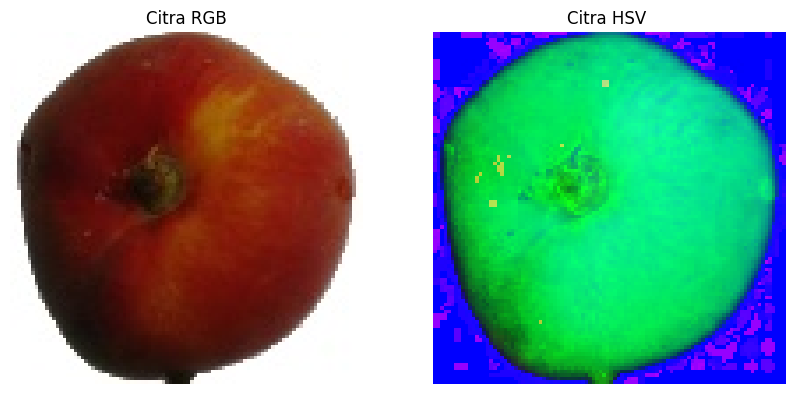

In [ ]:
import matplotlib.pyplot as plt

# Pilih satu contoh gambar untuk ditampilkan
idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,5))

# Tampilan RGB
plt.subplot(1,2,1)
plt.imshow(X[idx])
plt.title("Citra RGB")
plt.axis("off")

# Tampilan HSV (biasanya terlihat berbeda)
plt.subplot(1,2,2)
plt.imshow(X_hsv[idx])
plt.title("Citra HSV ")
plt.axis("off")

plt.show()


##Konversi RGB → Grayscale

In [ ]:
import cv2

X_Gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in X])

print("X Gray shape:", X_Gray.shape)

X Gray shape: (16491, 100, 100)


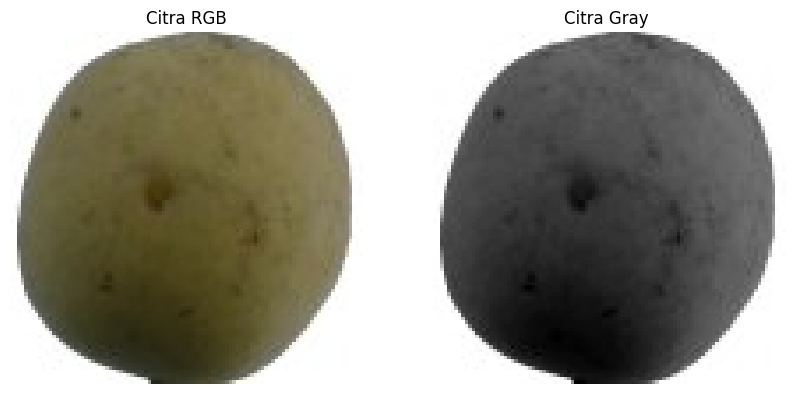

In [ ]:
import matplotlib.pyplot as plt

# Pilih satu contoh gambar untuk ditampilkan
idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,5))

# Tampilan RGB
plt.subplot(1,2,1)
plt.imshow(X[idx])
plt.title("Citra RGB")
plt.axis("off")

# Tampilan HSV (biasanya terlihat berbeda)
plt.subplot(1,2,2)
plt.imshow(X_Gray[idx],cmap="gray")
plt.title("Citra Gray ")
plt.axis("off")

plt.show()

##Filtering(Median Filtering),

In [ ]:
# Apply Median Filtering
X_Gray_Filtered = np.array([cv2.medianBlur(img, 3) for img in X_Gray])

print("X Gray Filtered shape:", X_Gray_Filtered.shape)

X Gray Filtered shape: (16491, 100, 100)


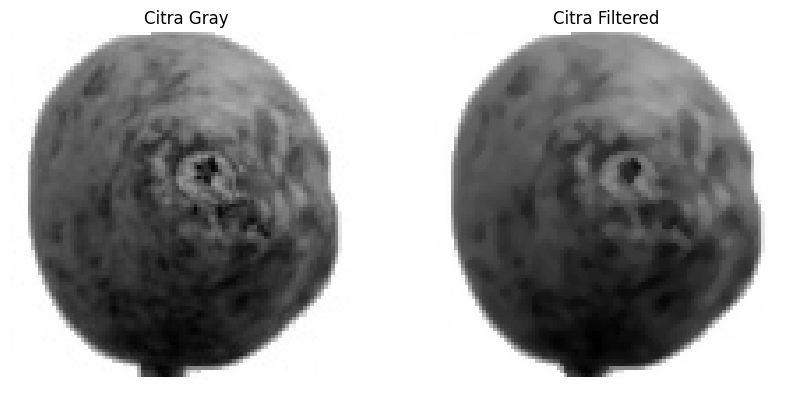

In [ ]:
import matplotlib.pyplot as plt

# Pilih satu contoh gambar untuk ditampilkan
idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,5))

# Tampilan RGB
plt.subplot(1,2,1)
plt.imshow(X_Gray[idx], cmap="gray")
plt.title("Citra Gray")
plt.axis("off")

# Tampilan HSV (biasanya terlihat berbeda)
plt.subplot(1,2,2)
plt.imshow(X_Gray_Filtered[idx],cmap="gray")
plt.title("Citra Filtered ")
plt.axis("off")

plt.show()

##Segmentasi Objek

In [ ]:
X_Mask = []
X_Gray_Segmented = []

for img in X_Gray_Filtered:
    # Otsu thresholding
    _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Apply mask agar background hilang
    segmented = cv2.bitwise_and(img, img, mask=mask)

    X_Mask.append(mask)
    X_Gray_Segmented.append(segmented)

# Convert ke numpy array
X_Mask = np.array(X_Mask)
X_Gray_Segmented = np.array(X_Gray_Segmented)

print("Mask dataset shape:", X_Mask.shape)
print("Segmented grayscale shape:", X_Gray_Segmented.shape)

Mask dataset shape: (16491, 100, 100)
Segmented grayscale shape: (16491, 100, 100)


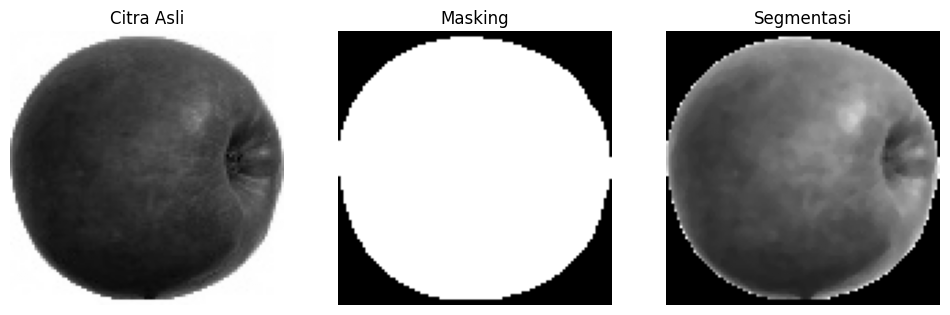

In [ ]:
idx = np.random.randint(0, len(X_Gray_Segmented))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_Gray[idx], cmap='gray')
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(X_Mask[idx], cmap='gray')
plt.title("Masking")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(X_Gray_Segmented[idx], cmap='gray')
plt.title("Segmentasi")
plt.axis("off")

plt.show()

##Histogram Equalization

In [ ]:
# Apply Histogram Equalization
X_Gray_Equalized = np.array([cv2.equalizeHist(img) for img in X_Gray_Segmented])

print("X Gray After Equalization shape:", X_Gray_Equalized.shape)

X Gray After Equalization shape: (16491, 100, 100)


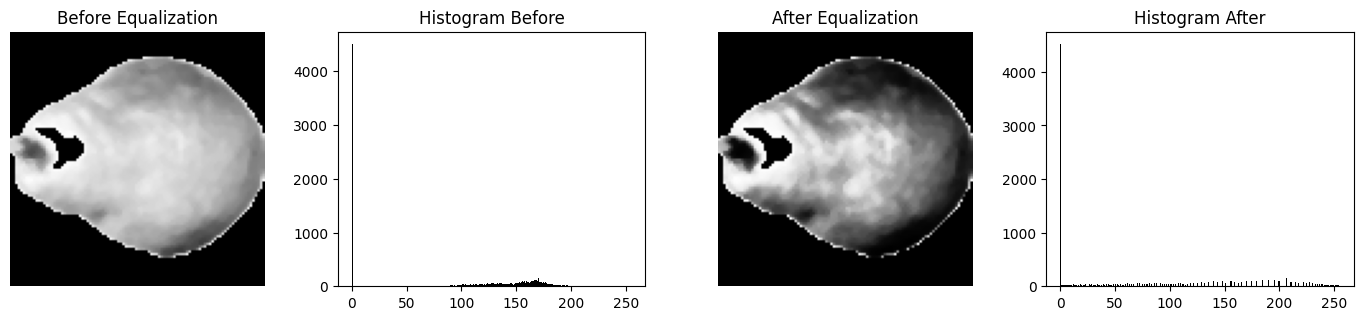

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pilih satu sampel secara random
idx = np.random.randint(0, len(X_Gray_Equalized))

before = X_Gray_Segmented[idx]      # sebelum equalize
after  = X_Gray_Equalized[idx]     # sesudah equalize

plt.figure(figsize=(14,6))

# --------------------------------
# 1️⃣ Gambar sebelum Equalization
# --------------------------------
plt.subplot(2,4,1)
plt.imshow(before, cmap="gray")
plt.title("Before Equalization")
plt.axis("off")

# Histogram sebelum
plt.subplot(2,4,2)
plt.hist(before.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram Before")


# --------------------------------
# 2️⃣ Gambar setelah Equalization
# --------------------------------
plt.subplot(2,4,3)
plt.imshow(after, cmap="gray")
plt.title("After Equalization")
plt.axis("off")

# Histogram sesudah
plt.subplot(2,4,4)
plt.hist(after.ravel(), bins=256, range=(0,255), color='black')
plt.title("Histogram After")

plt.tight_layout()
plt.show()

##Normalisasi

###RGB

In [ ]:
# Normalisasi piksel RGB (dari 0-255 -> 0-1)

X_Normalized = X.astype("float32") / 255.0

print("X Normalized shape:", X_Normalized.shape)
print("Contoh nilai sebelum:", X[0][0][0])
print("Contoh nilai sesudah:", X_Normalized[0][0][0])
print("Rentang nilai setelah normalisasi:", np.min(X_Normalized),"-",np.max(X_Normalized))


X Normalized shape: (16491, 100, 100, 3)
Contoh nilai sebelum: [255 255 255]
Contoh nilai sesudah: [1. 1. 1.]
Rentang nilai setelah normalisasi: 0.0 - 1.0


###Gray

In [ ]:
# Normalisasi piksel RGB (dari 0-255 -> 0-1)

X_Gray_Normalized = X_Gray_Filtered.astype("float32") / 255.0

print("X_Gray Normalized shape:", X_Gray_Normalized.shape)
print("Contoh nilai sebelum:", X_Gray[0][0][0])
print("Contoh nilai sesudah:", X_Gray_Normalized[0][0][0])
print("Rentang nilai setelah normalisasi:", np.min(X_Gray_Normalized),"-",np.max(X_Gray_Normalized))


X_Gray Normalized shape: (16491, 100, 100)
Contoh nilai sebelum: 255
Contoh nilai sesudah: 1.0
Rentang nilai setelah normalisasi: 0.0 - 1.0


#Ekstraksi Fitur

##Ekstraksi Fitur Warna RGB HSV

In [ ]:
import cv2
import numpy as np
import pandas as pd

# ==========================================================
# FUNGSI EKSTRAKSI FITUR WARNA (HISTOGRAM)
# ==========================================================
# Fungsi ini menghitung histogram warna per channel (misal: R,G,B atau H,S,V)
# Histogram lalu dinormalisasi dan digabungkan menjadi satu vektor fitur

def extract_color_features(image_data, color_space="RGB", bins=8):
    features = []
    for img in image_data:
        hist_features = []
        for i in range(img.shape[-1]):  # Loop setiap channel warna
            # Hitung histogram untuk setiap channel
            hist = cv2.calcHist([img.astype(np.float32)], [i], None, [bins], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            hist_features.extend(hist)
        features.append(hist_features)
    return np.array(features)

# ==========================================================
# EKSTRAKSI FITUR RGB
# ==========================================================

print("=== EKSTRAKSI FITUR WARNA RGB DIMULAI ===")

# X_Normalized berisi citra RGB dengan skala 0–1.
# Untuk perhitungan histogram, OpenCV lebih stabil apabila memakai rentang 0–255.
# Maka dari itu, citra dikembalikan ke rentang 0–255 sebelum diproses.

X_rgb_for_hist = (X_Normalized * 255).astype(np.uint8)

# Ekstraksi histogram RGB
rgb_features = extract_color_features(X_rgb_for_hist, color_space="RGB")

# Simpan ke CSV
df_rgb_features = pd.DataFrame(rgb_features)
df_rgb_features.to_csv("fitur_warna_rgb.csv", index=False)

print("=== EKSTRAKSI FITUR WARNA RGB SELESAI ===")


# ==========================================================
# EKSTRAKSI FITUR HSV
# ==========================================================

print("\n=== EKSTRAKSI FITUR WARNA HSV DIMULAI ===")

# Pada OpenCV:
#   H (Hue)  : range 0–179
#   S (Saturation) : range 0–255
#   V (Value): range 0–255
# Oleh karena itu, histogram perlu memakai rentang yang sesuai.

def extract_hsv_color_features(image_data, bins=8):
    features = []
    for img_hsv in image_data:
        hist_features = []

        # Histogram channel H (Hue)
        hist_h = cv2.calcHist([img_hsv], [0], None, [bins], [0, 180])
        hist_h = cv2.normalize(hist_h, hist_h).flatten()
        hist_features.extend(hist_h)

        # Histogram channel S dan V
        for i in range(1, 3):  # Loop channel S (1) dan V (2)
            hist = cv2.calcHist([img_hsv], [i], None, [bins], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            hist_features.extend(hist)

        features.append(hist_features)

    return np.array(features)

# Ekstraksi fitur HSV
hsv_features = extract_hsv_color_features(X_hsv)

# Simpan CSV
df_hsv_features = pd.DataFrame(hsv_features)
df_hsv_features.to_csv("fitur_warna_hsv.csv", index=False)

print("=== EKSTRAKSI FITUR WARNA HSV SELESAI ===")

print(f"\nShape fitur warna RGB: {rgb_features.shape}")
print(f"Shape fitur warna HSV: {hsv_features.shape}")

=== EKSTRAKSI FITUR WARNA RGB DIMULAI ===
=== EKSTRAKSI FITUR WARNA RGB SELESAI ===

=== EKSTRAKSI FITUR WARNA HSV DIMULAI ===
=== EKSTRAKSI FITUR WARNA HSV SELESAI ===

Shape fitur warna RGB: (16491, 24)
Shape fitur warna HSV: (16491, 24)


##Fitur Tekstur LBP

In [ ]:
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern

# Konfigurasi LBP
radius = 3
n_points = 8 * radius # 26 fitur

texture_features = []

print("=== EKSTRAKSI FITUR TEKSTUR DIMULAI ===")

for i in range(len(X_Gray_Normalized)):

    # Ambil 2D grayscale (H, W)
    gray_img = X_Gray_Normalized[i].squeeze()   # (H, W)

    # Ubah citra dari (float 0–1) menjadi uint8 (0–255)
    gray_uint8 = (gray_img * 255).astype("uint8")

    # Hitung LBP pada citra integer
    lbp = local_binary_pattern(gray_uint8, n_points, radius, method='uniform')

    # Histogram uniform LBP
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    # Normalisasi histogram
    hist = hist / (hist.sum() + 1e-6)

    texture_features.append(hist)

#simpan fitur tekstur ke csv
df_texture = pd.DataFrame(texture_features)
df_texture.to_csv("fitur_tekstur_lbp.csv", index=False)

print("=== EKSTRAKSI FITUR TEKSTUR SELESAI ===")

texture_features = np.array(texture_features)

print("Shape fitur tekstur:", texture_features.shape)

=== EKSTRAKSI FITUR TEKSTUR DIMULAI ===
=== EKSTRAKSI FITUR TEKSTUR SELESAI ===
Shape fitur tekstur: (16491, 26)


##Fitur Bentuk HOG

In [ ]:
from skimage.feature import hog
import numpy as np

# Konfigurasi HOG
orientations = 9              # jumlah arah gradien
pixels_per_cell = (20, 20)    # ukuran sel: 20x20 piksel
cells_per_block = (2, 2)      # normalisasi blok: 2x2 sel

shape_features = []

print("=== EKSTRAKSI FITUR BENTUK (HOG) DIMULAI ===")

for i in range(len(X_Gray_Normalized)):

    # Ambil grayscale 2D (H, W)
    gray_img = X_Gray_Normalized[i].squeeze()

    # Ekstraksi HOG
    hog_feature = hog(
        gray_img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    shape_features.append(hog_feature) # Simpan fitur sementara di RAM

# Simpan fitur di csv
df_shape = pd.DataFrame(shape_features)
df_shape.to_csv("fitur_bentuk_hog.csv", index=False)

print("=== EKSTRAKSI FITUR BENTUK (HOG) SELESAI ===")

shape_features = np.array(shape_features)

print("Shape fitur bentuk:", shape_features.shape)

=== EKSTRAKSI FITUR BENTUK (HOG) DIMULAI ===
=== EKSTRAKSI FITUR BENTUK (HOG) SELESAI ===
Shape fitur bentuk: (16491, 576)


##PCA

In [ ]:
labels = Y
print("Variable 'labels' successfully assigned from 'Y'.")

Variable 'labels' successfully assigned from 'Y'.


Sanity check OK — semua fitur dan label punya jumlah sampel yang sama: 16491
Shape gabungan fitur (N, D): (16491, 650)
Standarisasi selesai. Mean (kolom contoh): [ 0.  0. -0. -0.  0.]

Explained variance ratio (per komponen):
PC1: 0.1050
PC2: 0.0937
PC3: 0.0775
PC4: 0.0560
PC5: 0.0343
PC6: 0.0260
PC7: 0.0255
PC8: 0.0231
PC9: 0.0202
PC10: 0.0201

Cumulative explained variance (10 komponen): 0.4814146721662113

Scaler dan PCA disimpan di folder 'models/'
Hasil PCA disimpan di: /content/features_pca.csv


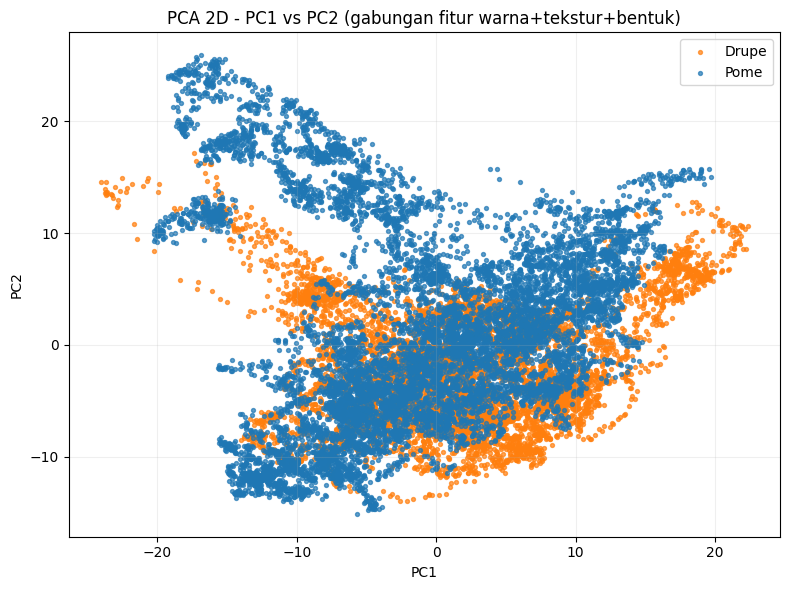

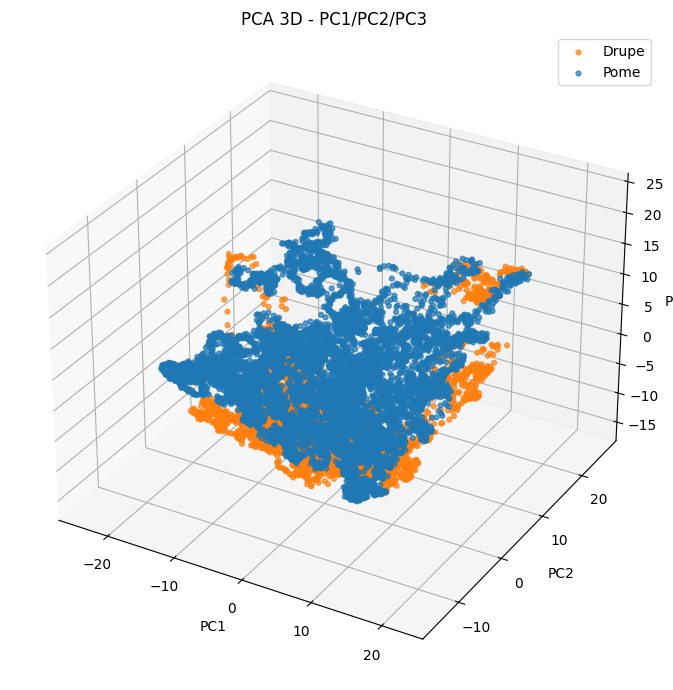

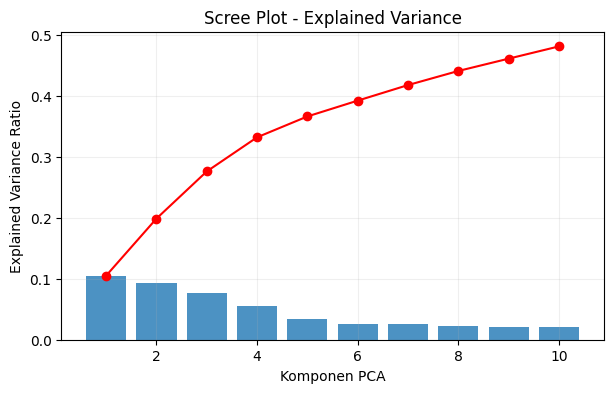

In [ ]:
# =========================
# PCA PIPELINE - Gabung fitur + PCA + visualisasi
# Jalankan setelah ekstraksi fitur selesai
# Variabel input yg diharapkan sudah ada di sesi:
#  - rgb_features        -> np.array shape (N, F_rgb)
#  - hsv_features        -> np.array shape (N, F_hsv)
#  - texture_features    -> np.array shape (N, F_lbp)
#  - shape_features      -> np.array shape (N, F_hog)
#  - labels              -> array/list length N, berisi nama kelas (misal "Apple 11", "Pear 5", dst.)
#  - kategori_labels     -> (opsional) array/list length N, "Pome" / "Drupe". Jika belum ada, akan dibuat dari labels
#  - file_names          -> (opsional) array/list length N, nama file. Jika tidak ada, digenerate "img_i.jpg"
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle
from mpl_toolkits.mplot3d import Axes3D  # untuk 3D plotting

# -------------------------
# 1. Siapkan label / file names (sesuaikan jika variable berbeda)
# -------------------------
# Pastikan variable labels ada — kalau tidak ada, ubah sesuai environmentmu.
try:
    labels  # jika ada, lanjut
except NameError:
    raise NameError("Variable 'labels' (array nama kelas per gambar) tidak ditemukan. Pastikan kamu punya 'labels' (atau Y) di workspace.")

# Convert ke numpy
labels = np.array(labels)

# Jika kategori_labels tidak ada, buat dari labels (prefix 'Apple'/'Pear' -> Pome, else Drupe)
try:
    kategori_labels = np.array(kategori_labels)
except NameError:
    kategori_labels = np.array(["Pome" if (("Apple" in str(l)) or ("Pear" in str(l))) else "Drupe" for l in labels])

# Jika file_names tidak ada, generate
try:
    file_names = np.array(file_names)
except NameError:
    file_names = np.array([f"img_{i}.jpg" for i in range(len(labels))])

# -------------------------
# 2. Sanity check: panjang semua fitur harus sama N
# -------------------------
features_list = {
    "rgb": rgb_features,
    "hsv": hsv_features,
    "lbp": texture_features,
    "hog": shape_features
}

N = len(labels)
for name, arr in features_list.items():
    if arr is None:
        raise ValueError(f"Fitur {name} tidak ditemukan (None).")
    if len(arr) != N:
        raise ValueError(f"Jumlah sampel fitur '{name}' = {len(arr)} != jumlah label {N}. Periksa urutan/ekstraksi.")

print("Sanity check OK — semua fitur dan label punya jumlah sampel yang sama:", N)

# -------------------------
# 3. Gabungkan fitur menjadi 1 matriks
# -------------------------
X_all = np.concatenate([features_list["rgb"], features_list["hsv"], features_list["lbp"], features_list["hog"]], axis=1)
print("Shape gabungan fitur (N, D):", X_all.shape)

# -------------------------
# 4. Standarisasi fitur (mean=0, std=1) - penting sebelum PCA
# -------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X_all)
print("Standarisasi selesai. Mean (kolom contoh):", np.round(X_std.mean(axis=0)[:5], 5))

# -------------------------
# 5. PCA - fit & transform
#    - Simpan explained variance
#    - Pilih n_components (misal ambil 10 pertama, dan juga visualisasi 2D/3D)
# -------------------------
pca = PCA(n_components=10, random_state=42)  # ambil 10 komponen pertama (bisa disesuaikan)
X_pca = pca.fit_transform(X_std)

explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

print("\nExplained variance ratio (per komponen):")
for i, r in enumerate(explained_ratio, 1):
    print(f"PC{i}: {r:.4f}")

print("\nCumulative explained variance (10 komponen):", cum_explained[-1])

# -------------------------
# 6. Simpan scaler & PCA object untuk reuse
# -------------------------
os.makedirs("models", exist_ok=True)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("models/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("\nScaler dan PCA disimpan di folder 'models/'")

# -------------------------
# 7. Simpan hasil transformasi PCA ke CSV (sertakan label)
# -------------------------
cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=cols)
df_pca.insert(0, "file", file_names)
df_pca.insert(0, "kelas", labels)
df_pca.insert(0, "kategori", kategori_labels)

csv_out = "/content/features_pca.csv"
df_pca.to_csv(csv_out, index=False)
print("Hasil PCA disimpan di:", csv_out)

# -------------------------
# 8. Visualisasi PCA 2D
# -------------------------
plt.figure(figsize=(8,6))
unique_kat = np.unique(kategori_labels)
colors = {"Pome":"tab:blue", "Drupe":"tab:orange"}
for kat in unique_kat:
    mask = (kategori_labels == kat)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=kat, s=8, alpha=0.7, c=colors.get(kat,"gray"))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D - PC1 vs PC2 (gabungan fitur warna+tekstur+bentuk)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# -------------------------
# 9. Visualisasi PCA 3D (PC1, PC2, PC3) - jika PCA punya >=3 komponen
# -------------------------
if X_pca.shape[1] >= 3:
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    for kat in unique_kat:
        mask = (kategori_labels == kat)
        ax.scatter(X_pca[mask,0], X_pca[mask,1], X_pca[mask,2],
                   label=kat, s=12, alpha=0.7, c=colors.get(kat,"gray"))
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("PCA 3D - PC1/PC2/PC3")
    ax.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 10. Plot explained variance ratio (scree plot)
# -------------------------
plt.figure(figsize=(7,4))
plt.bar(range(1, len(explained_ratio)+1), explained_ratio, alpha=0.8)
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o', color='red')
plt.xlabel("Komponen PCA")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - Explained Variance")
plt.grid(alpha=0.2)
plt.show()